## Introduction to Quantum Computing: Labs

### Lab 1: First Steps with Quantum Circuits and Measurements

Welcome to the first lab.
We will work only with very small quantum circuits and observe what happens during individual measurements.

As a reminder:

- A **qubit** is the quantum-mechanical analogue of a bit.
- However, when we perform a measurement we always obtain classical outcomes, namely `0` or `1`.
- For quantum states we use the Dirac notation (kets), i.e. $\ket{0}$ and $\ket{1}$.
- Some quantum gates change the state deterministically, while others create superpositions where measurements can yield random outcomes.
- A measurement destroys the superposition of a quantum state, and the quantum state *collapses* into the measured state.

In this lab we use **Qiskit** to construct and visualize quantum circuits.
In addition, we use a helper library `qc_lecture_tools` that provides simple functions for evaluating quantum circuits and displaying the results.

If you have not done so yet, follow the instructions in the ``README.md`` to set up your Python environment. Do not hesitate to ask if something does not work or if you need help with the setup.

In [90]:
from qiskit import QuantumCircuit
from qc_lecture_tools.sampling import measure_quantum_circuit

A quantum circuit is created using the class `QuantumCircuit`.
The number given as an argument specifies how many qubits the circuit contains.

Example of an empty circuit with one qubit:

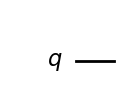

In [91]:
num_qubits = 1
quantum_circuit = QuantumCircuit(num_qubits)
quantum_circuit.draw("mpl")

Quantum gates are appended to the circuit as methods and are simply called sequentially. The index of the desired qubit is passed as an argument. For a two-qubit gate, the control and target qubits are specified.

Examples:

- `quantum_circuit.x(0)` inserts an X gate (also called a NOT gate) on qubit 0.
- `quantum_circuit.h(0)` inserts a Hadamard gate on qubit 0.
- `quantum_circuit.cx(0, 1)` inserts a CNOT gate with control qubit 0 and target qubit 1.

**Important:** In Python, counting starts at 0. Therefore, the first qubit has index 0.

### Exercise 1: Creating Your First Quantum Circuits

In this exercise you should first construct simple quantum circuits and display them using `draw("mpl")`.

This allows you to see how Qiskit represents a circuit graphically.

**Exercise 1.1:** Create a quantum circuit with **one qubit** and add **one X gate**. Display the circuit using `draw("mpl")`.

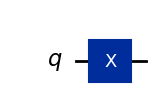

In [92]:
quantum_circuit = QuantumCircuit(1)
quantum_circuit.x(0)
quantum_circuit.draw("mpl")

**Exercise 1.2:** Create a quantum circuit with **one qubit**, first add a **NOT gate** and then a **Hadamard gate**. Display the circuit using `draw("mpl")`.

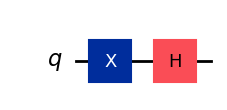

In [93]:
quantum_circuit = QuantumCircuit(1)
quantum_circuit.x(0)
quantum_circuit.h(0)
quantum_circuit.draw("mpl")

**Exercise 1.3:** Create a quantum circuit with **two qubits**, first add a **Hadamard gate** to the first qubit (index 0), and then a **CNOT gate** with control qubit 0 and target qubit 1. Display this circuit as well.

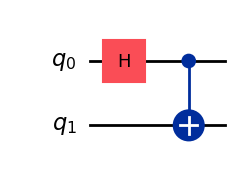

In [94]:
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.cx(0,1)
quantum_circuit.draw("mpl")

### Exercise 2: Measuring Quantum Circuits

Now we will not only look at the circuits themselves, but also at their **measurement results**.

For this we use the function `measure_quantum_circuit` from `qc_lecture_tools.sampling`.
This function performs a measurement of the quantum circuit and displays the observed classical result.

Example:

>```python
>measure_quantum_circuit(quantum_circuit)
>```

For the following exercises, execute the cells **multiple times** in order to verify the possibly occurring random results.

**Exercise 2.1:** Create an **empty quantum circuit** with one qubit and measure it using `measure_quantum_circuit(quantum_circuit)`.
Execute the cell multiple times.

Question: Which state do you observe?

In [95]:
quantum_circuit = QuantumCircuit(1)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

**Exercise 2.2:** Now apply an **X gate** to a qubit and measure the circuit multiple times.

Question: Which state do you observe now?

In [96]:
quantum_circuit = QuantumCircuit(1)
quantum_circuit.x(0)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

**Exercise 2.3:** Apply an **H gate** to a qubit and measure the circuit multiple times.

Questions:

- Which states do you observe?
- Approximately how often does `0` appear and how often `1`?

In [97]:
quantum_circuit = QuantumCircuit(1)
quantum_circuit.h(0)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

**Exercise 2.4:** Create a circuit with **two qubits** and apply **a Hadamard gate to both qubits**. Measure the circuit multiple times.

Question: Which states do you observe now?

In [98]:
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.h(1)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

**Exercise 2.5:** Create a circuit with **two qubits**, but apply the **Hadamard gate only to the first qubit**. Measure the circuit multiple times.

Question: Which results do you observe now and what has changed compared to the previous exercise?

In [99]:
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

#### Intermediate remark

Up to this point we can already see an important difference between classical and quantum operations:

- Some gates always produce the same result when measured.
- Other gates lead to random outcomes.
- With multiple qubits, bitstrings such as `00`, `01`, `10`, or `11` appear.

### Exercise 3: Two Qubits and CNOT

Now we combine a Hadamard gate with a **CNOT gate** (`cx`).

The CNOT gate operates on two qubits:

- The first qubit is the **control qubit**.
- The second qubit is the **target qubit**.
- The target qubit is flipped exactly when the control qubit has the value `1`.

In Qiskit we write, for example:

```python
quantum_circuit.cx(0, 1)
```

This means: control qubit `0`, target qubit `1`.

**Exercise 3.1:** Create a circuit with **two qubits**. First apply a **Hadamard gate to qubit 0**, then a **CNOT gate** with qubit 0 as the control qubit and qubit 1 as the target qubit. Measure the circuit multiple times.

Question: Which results do you observe?

In [100]:
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.cx(0,1)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

**Exercise 3.2:** Take the circuit from Exercise 3.1 and then additionally apply an **X gate to the other qubit**, i.e. to the qubit on which the CNOT previously acted. Measure again multiple times.

Question: Which results do you observe now?

In [101]:
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.cx(0,1)
quantum_circuit.x(1)
measure_quantum_circuit(quantum_circuit)

<IPython.core.display.Math object>

**Bonus exercise:**

If you already have some experience with Python, you can also automatically count the observed states.

For this, use the option ``latex=False`` in the measurement function:

>```python
>measure_quantum_circuit(quantum_circuit, latex=False)
>```

Then the measured state is not returned as formatted output but as a string, for example ``"10"``.
You can then further process this return value in Python.
Execute the measurement several times in succession and use, for example, a Python dictionary (or another suitable data structure) to count how often each measured state occurs.
In this way you can systematically analyze the frequencies of the measurement outcomes.

In [102]:
def count_measurements(quantum_circuit: QuantumCircuit, num_measurements:int) -> dict:
    """ 
    Function to count the measurements of a quantum circuit

    Args:
        quantum_circuit (QuantumCircuit): The quantum circuit to measure
        num_measurements (int): The number of measurements to perform

    Returns:
        dict: A dictionary with the counts of the measurements
    """
    
    # Empty dictionary to store the counts
    counts = {}
    for _ in range(num_measurements):
        # Get the bitstring from the measurement
        bitstring = measure_quantum_circuit(quantum_circuit, latex=False)
        # Update the counts in the dictionary
        if bitstring in counts:
            counts[bitstring] += 1
        else:
            counts[bitstring] = 1
    return counts


In [103]:
# Counts form Exercise 2.3
quantum_circuit = QuantumCircuit(1)
quantum_circuit.h(0)
counts = count_measurements(quantum_circuit, 1000)
print(counts)

{'1': 525, '0': 475}


In [104]:
# Counts from Exercise 3.1
quantum_circuit = QuantumCircuit(2)
quantum_circuit.h(0)
quantum_circuit.cx(0,1)
counts = count_measurements(quantum_circuit, 1000)
print(counts)

{'11': 503, '00': 497}
